# Cuaderno 01B. `usecols`, `merge` y visualización con Matplotlib

**Programación para Analítica de Datos**

Este cuaderno sirve como puente antes del cuaderno de preprocesamiento/ETL. El objetivo es trabajar con varios archivos CSV, seleccionar únicamente la información necesaria, relacionar tablas y construir un DataFrame unificado para análisis.

### Objetivos
Al finalizar podrá:

- cargar varios archivos CSV con `pandas`;
- leer solo columnas necesarias mediante `usecols`;
- reconocer la diferencia entre `inner`, `left`, `right` y `outer`;
- construir un DataFrame unificado con varios `merge`;
- crear un histograma y un gráfico de cajas con Matplotlib.

> **Regla de trabajo:** ejecute las celdas en orden y observe qué cambia en cada paso. No es necesario memorizar la sintaxis; interesa comprender qué información entra, cómo se relaciona y qué resultado produce cada operación.

## 1. Caso de trabajo

Un restaurante almacena su información en tres archivos:

- `ventas.csv`: cada fila representa una transacción;
- `clientes.csv`: contiene información básica de los clientes;
- `productos.csv`: contiene el catálogo de productos.

La información está separada porque cada archivo describe una entidad diferente. Para analizar las ventas necesitamos **relacionar** esas tablas mediante columnas identificadoras como `cliente_id` y `producto_id`.

In [1]:
# %%
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)

## 2. Leer solo las columnas necesarias con `usecols`

Los archivos originales contienen columnas que no se requieren para este análisis. `usecols` permite indicar desde la lectura cuáles columnas queremos cargar.

Esto hace más explícito el análisis y evita incorporar información que no será utilizada.

In [4]:
# Al escribir columnas_ventas = ["venta_id", "fecha"...], solo le estás diciendo a Python:
# "Oye, guarda este grupo de textos en una caja llamada columnas_ventas". Python no tiene 
# idea de si esos nombres pertenecen a un archivo CSV, a una base de datos o a los nombres 
# de tus mascotas. Solo guarda el texto en la memoria. Por eso es imposible que falle ahí

columnas_ventas = ["venta_id", "fecha", "cliente_id", "producto_id",
    "cantidad", "precio_unitario", "sucursal"]
columnas_clientes = ["cliente_id", "ciudad", "segmento", "edad"]
columnas_productos = ["producto_id", "producto", "categoria", "costo_unitario"]

In [ ]:
#El texto que pones a la izquierda (df_ventas, data, o el nombre que tú quieras) es solo el 
# contenedor donde guardas esa tabla que acabas de jalar para poder usarla después.

df_ventas = pd.read_csv("ventas.csv", usecols=columnas_ventas)
df_clientes = pd.read_csv("clientes.csv", usecols=columnas_clientes)
df_productos = pd.read_csv("productos.csv", usecols=columnas_productos)

In [6]:
# shape te da las dimensiones exactas (filas y columnas) y display muestra un resumen 
# visual de la tabla, mientras que escribir solo el nombre de la variable sí funciona 
# para mostrar la tabla pero solo en ciertos entornos como Jupyter Notebooks.

print("Ventas:", df_ventas.shape)
print("Clientes:", df_clientes.shape)
print("Productos:", df_productos.shape)

display(df_ventas.head())
display(df_clientes.head())
display(df_productos.head())

Ventas: (120, 7)
Clientes: (20, 4)
Productos: (8, 4)


,venta_id,fecha,cliente_id,producto_id,cantidad,precio_unitario,sucursal
0,1001,2026-08-24,118,206,1,6000,Norte
1,1002,2026-08-30,115,206,1,7000,Centro
2,1003,2026-08-27,107,204,3,31000,Centro
3,1004,2026-08-03,109,201,2,24000,Occidente
4,1005,2026-08-25,119,208,1,21000,Occidente


,cliente_id,ciudad,segmento,edad
0,101,Bogotá,Frecuente,29
1,102,Bogotá,Ocasional,41
2,103,Chía,Frecuente,35
3,104,Bogotá,Nuevo,27
4,105,Cajicá,Ocasional,33


,producto_id,producto,categoria,costo_unitario
0,201,Bowl pollo,Almuerzo,14000
1,202,Bowl vegetariano,Almuerzo,12000
2,203,Pasta pesto,Almuerzo,15000
3,204,Pasta boloñesa,Almuerzo,17000
4,205,Jugo natural,Bebida,5000


### ¿Qué aporta `usecols`?

Observe que los CSV contienen más información, pero los DataFrames solo incluyen las columnas definidas en las listas anteriores.

La idea es sencilla:

```python
pd.read_csv("archivo.csv", usecols=["columna_1", "columna_2"])
```

Primero se didentifica la información relevante y luego se carga.

## 3. Preparar una columna antes de unir tablas

La fecha llega desde el CSV como texto. Antes de continuar la convertimos a tipo fecha.

In [12]:
df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"])

print(df_ventas.dtypes)

venta_id                    int64
fecha              datetime64[us]
cliente_id                  int64
producto_id                 int64
cantidad                    int64
precio_unitario             int64
sucursal                      str
dtype: object


## 4. Comprender `merge`

`merge` relaciona dos DataFrames usando una columna común.

En este caso:

- `ventas.cliente_id` se relaciona con `clientes.cliente_id`;
- `ventas.producto_id` se relaciona con `productos.producto_id`.

El argumento `how=` define qué filas se conservan.

| `how` | ¿Qué conserva? |
|---|---|
| `"inner"` | Solo las claves que aparecen en ambos DataFrames |
| `"left"` | Todas las filas del DataFrame de la izquierda |
| `"right"` | Todas las filas del DataFrame de la derecha |
| `"outer"` | Todas las claves de ambos DataFrames |

Vamos a ejecutar las cuatro opciones sobre las mismas dos tablas para comparar el resultado.

### 4.1 `inner`: solo coincidencias

In [ ]:
# El programa no adivina. Tú, como analista que conoce los datos, le estás diciendo:
# "Busca en ambas tablas la columna cliente_id porque esa es la llave de unión".
# El comando how="inner" (que significa unión interna) le dice a Pandas: 
# "Tráeme únicamente las filas donde el cliente_id exista en ambas tablas al mismo tiempo".
# Por lo tanto, el Cliente A sí aparecerá en el resultado final (con sus datos de venta y 
# sus datos personales juntos).El Cliente B quedará completamente por fuera del resultado 
# porque no tiene compras asociadas.
#  ¿Qué pasa con las demás columnas?Una vez que el inner encuentra a los clientes que sí 
# coinciden en ambas tablas, trae automáticamente todas las columnas que habías seleccionado
# previamente para ambas tablas (fecha, cantidad, precio_unitario de ventas + ciudad, segmento,
# edad de clientes) y las pega de lado a lado en una sola fila para cada compra.El comando final 
# len(merge_inner) que pusiste abajo simplemente cuenta el total de filas final para que veas 
# cuántas ventas quedaron registradas después del filtro.
# 

merge_inner = df_ventas.merge(
    df_clientes,
    on="cliente_id",
    how="inner")

print("Filas con inner:", len(merge_inner))
merge_inner.head()

Filas con inner: 115


,venta_id,fecha,cliente_id,producto_id,cantidad,precio_unitario,sucursal,ciudad,segmento,edad
0,1001,2026-08-24,118,206,1,6000,Norte,Bogotá,Ocasional,37
1,1002,2026-08-30,115,206,1,7000,Centro,Bogotá,Ocasional,34
2,1003,2026-08-27,107,204,3,31000,Centro,Chía,Nuevo,31
3,1004,2026-08-03,109,201,2,24000,Occidente,Cajicá,Frecuente,25
4,1005,2026-08-25,119,208,1,21000,Occidente,Cajicá,Frecuente,26


Con `inner`, una venta cuyo `cliente_id` no exista en el archivo de clientes no queda en el resultado.

### 4.2 `left`: conservar todas las ventas

In [ ]:
# how="inner": Solo conserva compras de clientes que sí existen en ambas tablas (puede achicar la tabla)
# .how="left": Mantiene todas las compras de la tabla izquierda pase lo que pase. 
# Si falta información del cliente a la derecha, rellena con NaN (vacío).

#tabla de la derecha (df_clientes) no tiene prioridad. El "Cliente B" (el cliente nuevo que jamás
# ha comprado) no existe en la tabla de ventas. Como el left solo conserva las filas que 
# ya existen en la tabla de la izquierda, el Cliente B se descarta por completo porque no hay
# ninguna venta a la cual pegarle sus datos.Entonces, te preguntarás: ¿El número de filas 
# con left siempre es igual al de la tabla original de ventas?El 99% de las veces, sí. Si
# cada venta corresponde a un solo cliente, len(merge_left) será exactamente igual a len(df_ventas).

#Como le diste prioridad a la tabla de la izquierda (df_ventas), el programa va a registrar 
# todas y cada una de las compras. Si la compra número 500 la hizo un cliente que no está 
# registrado en tu base de datos de clientes, Pandas no va a borrar la venta. En su lugar,
# dejará la venta intacta y en las columnas de información del cliente (ciudad, edad, segmento)
# colocará un NaN (vacío).

merge_left = df_ventas.merge(
    df_clientes,
    on="cliente_id",
    how="left"
)

print("Filas originales de ventas:", len(df_ventas))
print("Filas con left:", len(merge_left))

merge_left.loc[merge_left["ciudad"].isna()].head()

Filas originales de ventas: 120
Filas con left: 120


,venta_id,fecha,cliente_id,producto_id,cantidad,precio_unitario,sucursal,ciudad,segmento,edad
26,1027,2026-08-13,999,201,2,24000,Norte,NaN,NaN,NaN
53,1054,2026-08-25,999,205,2,10000,Occidente,NaN,NaN,NaN
79,1080,2026-08-18,999,202,2,22000,Centro,NaN,NaN,NaN
80,1081,2026-08-31,999,201,2,24000,Occidente,NaN,NaN,NaN
106,1107,2026-08-11,999,201,1,25000,Norte,NaN,NaN,NaN


`left` es útil cuando la tabla principal es `ventas` y queremos conservar todas las transacciones, incluso si alguna clave no encuentra correspondencia.

### 4.3 `right`: conservar todos los clientes

In [ ]:
# INNER (how="inner")
# Solo conserva las filas donde el 'cliente_id' coincide en AMBAS tablas.
# Ejemplo: Si un cliente no tiene compras, o una venta no tiene cliente registrado, se eliminan.

# LEFT (how="left")
# Manda la tabla de la IZQUIERDA (df_ventas). Conserva todas sus filas.
# Si una venta pertenece a un cliente que NO está en la tabla de clientes,
# la venta se mantiene y los datos del cliente se rellenan con espacios vacíos (NaN).
# Su tamaño final de filas suele ser igual al de la tabla de ventas original.

# RIGHT (how="right")
# Manda la tabla de la DERECHA (df_clientes). Conserva todos los clientes.
# Si hay clientes registrados que nunca han comprado nada, aparecerán en la tabla,
# pero todos sus datos de ventas se rellenarán con espacios vacíos (NaN).
# Su tamaño final dependerá de la cantidad de clientes y de cuántas compras tenga cada uno.

# inner: Solo la intersección (coincidencia exacta en ambas).left: Manda la tabla de la izquierda (Ventas).
# Su tamaño máximo suele ser el de ventas.right: Manda la tabla de la derecha (Clientes). 
# Su tamaño máximo se adapta a la de clientes.

merge_right = df_ventas.merge(
    df_clientes,
    on="cliente_id",
    how="right"
)

print("Filas con right:", len(merge_right))

merge_right.loc[merge_right["venta_id"].isna()].head()

Filas con right: 116


,venta_id,fecha,cliente_id,producto_id,cantidad,precio_unitario,sucursal,ciudad,segmento,edad
115,NaN,NaT,120,NaN,NaN,NaN,NaN,Bogotá,Nuevo,42


Con `right`, también aparecen clientes que no registran compras. En esas filas, las columnas provenientes de ventas quedan vacías (`NaN`).

### 4.4 `outer`: conservar todo y diagnosticar coincidencias

In [ ]:
# suponiendo o siguiendo la lineas de los anteriores codigos o librerias, aca debe ser conserve todo una todo y ya, es decir 
# se duplica las filas por q suma ambas tablas, y asi esten repetidos los clientes apareceran celdas vacias, creeria, o la otra opcion 
# puede ser que no deje todo sino una los datos que se repiten o son igules de cliente en ambas tablas y añada los que quedaron 
# sobrando

#El how="outer" (que significa unión externa completa) no duplica las filas por duplicarlas ni las suma a ciegas. 
# Lo que hace es actuar como una "red de seguridad total":Une lo que coincide: Primero busca los clientes que están 
# en ambas tablas y los junta perfectamente (igual que el inner).Añade lo que sobra a la izquierda: Trae las ventas 
# de clientes que no estaban registrados y rellena sus datos personales con vacíos (NaN) (igual que el left).Añade 
# lo que sobra a la derecha: Trae a los clientes que nunca han comprado nada y rellena sus datos de venta con vacíos 
# (NaN) (igual que el right).Es decir, el outer no deja a nadie por fuera. Une todo lo que puede y, lo que no puede unir, 
# lo añade al final rellenando los huecos con 

merge_outer = df_ventas.merge(
    df_clientes,
    on="cliente_id",
    how="outer",
    indicator=True
)

merge_outer["_merge"].value_counts()

# El truco de magia está en el parámetro indicator=True. Cuando le pones True a ese indicador, 
# le estás dando una orden explícita a Pandas:"Pandas, mientras vas juntando las tablas, 
# ve anotando en una columna nueva llamada estrictamente _merge de dónde sacaste cada fila".

_merge
both          115
left_only       5
right_only      1
Name: count, dtype: int64

In [ ]:
# Aca le esta indicando que solo muestrme de la columna de merge los datos q son both(me imagino que juntas)
# y traeme la informacion de estas columnas, pero aca viene mi pregunta, el both no seria los mismos datos del inner,
# a direrencia q no traigo todas las columnas de la tabla sino las que necedito, por medio de ese codifo de loc.

merge_outer.loc[
    merge_outer["_merge"] != "both",
    ["venta_id", "cliente_id", "ciudad", "segmento", "_merge"]
].head(10)

# Entonces... ¿Por qué hacer un outer y luego filtrar both, en vez de hacer un inner directamente?Te preguntarás: 
# "Si da el mismo resultado, ¿para qué dar tanta vuelta?". En el análisis de datos se hace esto por dos razones 
# principales:Eficiencia en la investigación: Al hacer el outer primero con el indicator=True, guardaste toda 
# la información del negocio en una sola tabla grande (merge_outer).Reutilización: Ahora, sin tener que volver 
# a cargar o procesar archivos, puedes usar esa misma tabla para diferentes reportes en celdas separadas:En una 
# celda filtras los both para ver el comportamiento de los clientes activos (esta celda).En la siguiente celda 
# podrías cambiar "both" por "right_only" para auditar rápidamente quién es el cliente que nunca ha comprado, usando la misma tabla.

,venta_id,cliente_id,ciudad,segmento,_merge
115,NaN,120,Bogotá,Nuevo,right_only
116,1027.0,999,NaN,NaN,left_only
117,1054.0,999,NaN,NaN,left_only
118,1080.0,999,NaN,NaN,left_only
119,1081.0,999,NaN,NaN,left_only
120,1107.0,999,NaN,NaN,left_only


La columna `_merge` permite reconocer tres situaciones:

- `both`: la clave aparece en ambas tablas;
- `left_only`: aparece únicamente en la tabla izquierda;
- `right_only`: aparece únicamente en la tabla derecha.

Esta opción es especialmente útil para revisar la calidad de las relaciones antes de construir el DataFrame final.

## 5. Comparar rápidamente los cuatro tipos de unión

In [18]:
comparacion_merge = pd.DataFrame({
    "tipo_merge": ["inner", "left", "right", "outer"],
    "numero_filas": [
        len(merge_inner),
        len(merge_left),
        len(merge_right),
        len(merge_outer)
    ]
})

comparacion_merge

,tipo_merge,numero_filas
0,inner,115
1,left,120
2,right,116
3,outer,121


## 6. Construir un DataFrame unificado

Para el análisis usaremos `ventas` como tabla principal. Por eso se aplicarán dos `left merge` consecutivos:

1. ventas + clientes;
2. resultado anterior + productos.

De esta forma se conserva cada transacción y se agregan atributos del cliente y del producto.

In [19]:
df_unificado = df_ventas.merge(
    df_clientes,
    on="cliente_id",
    how="left")

df_unificado = df_unificado.merge(
    df_productos,
    on="producto_id",
    how="left")

print(df_unificado.shape)
df_unificado.head()

(120, 13)


,venta_id,fecha,cliente_id,producto_id,cantidad,precio_unitario,sucursal,ciudad,segmento,edad,producto,categoria,costo_unitario
0,1001,2026-08-24,118,206,1,6000,Norte,Bogotá,Ocasional,37.0,Café americano,Bebida,2500
1,1002,2026-08-30,115,206,1,7000,Centro,Bogotá,Ocasional,34.0,Café americano,Bebida,2500
2,1003,2026-08-27,107,204,3,31000,Centro,Chía,Nuevo,31.0,Pasta boloñesa,Almuerzo,17000
3,1004,2026-08-03,109,201,2,24000,Occidente,Cajicá,Frecuente,25.0,Bowl pollo,Almuerzo,14000
4,1005,2026-08-25,119,208,1,21000,Occidente,Cajicá,Frecuente,26.0,Ensalada especial,Almuerzo,11000


## 7. Crear variables útiles para el análisis

A partir de columnas existentes calcularemos:

- `total_venta`: ingreso de la transacción;
- `costo_total`: costo estimado de los productos vendidos;
- `margen_bruto`: diferencia entre venta y costo.

In [20]:
df_unificado["total_venta"] = (df_unificado["cantidad"] * df_unificado["precio_unitario"])
df_unificado["costo_total"] = (df_unificado["cantidad"] * df_unificado["costo_unitario"])
df_unificado["margen_bruto"] = (df_unificado["total_venta"] - df_unificado["costo_total"])
df_unificado.head()

,venta_id,fecha,cliente_id,producto_id,cantidad,precio_unitario,sucursal,ciudad,segmento,edad,producto,categoria,costo_unitario,total_venta,costo_total,margen_bruto
0,1001,2026-08-24,118,206,1,6000,Norte,Bogotá,Ocasional,37.0,Café americano,Bebida,2500,6000,2500,3500
1,1002,2026-08-30,115,206,1,7000,Centro,Bogotá,Ocasional,34.0,Café americano,Bebida,2500,7000,2500,4500
2,1003,2026-08-27,107,204,3,31000,Centro,Chía,Nuevo,31.0,Pasta boloñesa,Almuerzo,17000,93000,51000,42000
3,1004,2026-08-03,109,201,2,24000,Occidente,Cajicá,Frecuente,25.0,Bowl pollo,Almuerzo,14000,48000,28000,20000
4,1005,2026-08-25,119,208,1,21000,Occidente,Cajicá,Frecuente,26.0,Ensalada especial,Almuerzo,11000,21000,11000,10000


## 8. Verificar el resultado del `merge`

In [21]:
columnas_clave = ["cliente_id", "ciudad", "segmento",
    "producto_id", "producto", "categoria"]

df_unificado[columnas_clave].isna().sum()

cliente_id     0
ciudad         5
segmento       5
producto_id    0
producto       0
categoria      0
dtype: int64

Los valores faltantes que aparezcan después de un `merge` pueden indicar que una clave de la tabla principal no tuvo correspondencia en la tabla auxiliar. Antes de eliminar o reemplazar esos datos conviene identificar la causa.

## 9. Una primera mirada estadística

In [22]:
df_unificado[["cantidad", "precio_unitario", "total_venta", "margen_bruto"]].describe().round(2)

,cantidad,precio_unitario,total_venta,margen_bruto
count,120.00,120.00,120.00,120.00
mean,1.82,20441.67,38016.67,17687.50
std,0.89,8327.13,26716.06,12153.44
min,1.00,6000.00,6000.00,3500.00
25%,1.00,11000.00,21000.00,10000.00
50%,2.00,22000.00,30000.00,15000.00
75%,2.00,28000.00,48000.00,22000.00
max,4.00,33000.00,128000.00,60000.00


## 10. Histograma con Matplotlib

Un histograma divide una variable numérica en intervalos y muestra cuántas observaciones quedan en cada uno.

Aquí observaremos la distribución de `total_venta`.

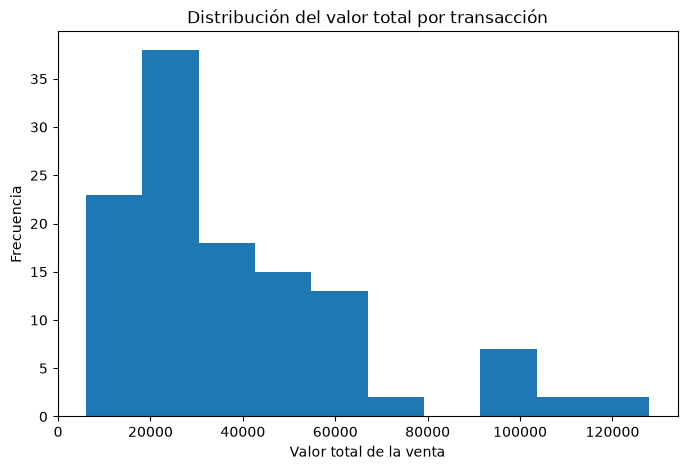

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df_unificado["total_venta"].dropna(), bins=10)

plt.title("Distribución del valor total por transacción")
plt.xlabel("Valor total de la venta")
plt.ylabel("Frecuencia")

plt.show()

**Para observar:** ¿la mayoría de las ventas se concentra en valores bajos, medios o altos? ¿Hay transacciones claramente alejadas del grupo principal?

## 11. Gráfico de cajas con Matplotlib

El gráfico de cajas resume la distribución mediante mediana, cuartiles y posibles valores atípicos.

Usaremos la misma variable para comparar lo que muestra el boxplot frente al histograma.

C:\Users\CSI\AppData\Local\Temp\ipykernel_15392\502933301.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_unificado["total_venta"].dropna(), vert=False)


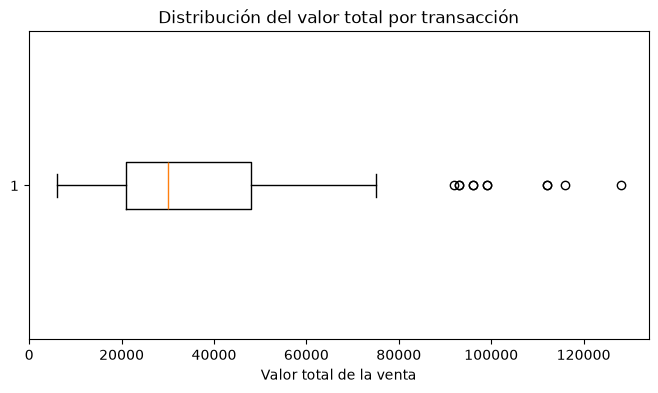

In [24]:
plt.figure(figsize=(8, 4))

plt.boxplot(df_unificado["total_venta"].dropna(), vert=False)

plt.title("Distribución del valor total por transacción")
plt.xlabel("Valor total de la venta")

plt.show()

### Lectura conjunta de los dos gráficos

El histograma permite ver la forma de la distribución.  
El gráfico de cajas resume posición, dispersión y posibles valores atípicos.

No son gráficos equivalentes, se complementan.

## 12. Consulta breve sobre el DataFrame unificado

Ya podemos combinar información que antes estaba separada. Por ejemplo, revisar ventas de una categoría específica.

In [25]:
ventas_almuerzo = df_unificado.loc[
    df_unificado["categoria"] == "Almuerzo",
    ["fecha", "sucursal", "producto", "cantidad", "total_venta", "segmento"]].copy()

ventas_almuerzo.head()

,fecha,sucursal,producto,cantidad,total_venta,segmento
2,2026-08-27,Centro,Pasta boloñesa,3,93000,Nuevo
3,2026-08-03,Occidente,Bowl pollo,2,48000,Frecuente
4,2026-08-25,Occidente,Ensalada especial,1,21000,Frecuente
5,2026-08-28,Centro,Pasta boloñesa,3,99000,Frecuente
6,2026-08-04,Occidente,Ensalada especial,1,21000,Nuevo


## 13. Exportar el resultado

In [26]:
df_unificado.to_csv("ventas_unificadas.csv", index=False)

print("Archivo creado: ventas_unificadas.csv")

Archivo creado: ventas_unificadas.csv


## Cierre

Antes de avanzar, responda brevemente:

1. ¿Qué ventaja tiene usar `usecols` desde `read_csv()` en lugar de cargar todas las columnas?
2. ¿Qué diferencia práctica encontró entre `inner` y `left`?
3. ¿Qué información aporta `indicator=True` en un `outer merge`?
4. ¿Por qué `left` fue una elección razonable para construir el DataFrame de ventas unificado?
5. ¿Qué observación puede obtener del histograma que no sea tan evidente en el gráfico de cajas, y viceversa?

*Idea central:* los datos pueden estar correctamente almacenados en archivos separados. El análisis comienza cuando se selecciona la información necesaria, se comprenden sus relaciones y se construye una tabla coherente para responder una pregunta.